## 1.  Data Loading & Initial Exploration


In [ ]:
import kagglehub
path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")
print(path)

100%|██████████| 339M/339M [00:01<00:00, 185MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/adarshsng/lending-club-loan-data-csv/versions/1


In [ ]:
import os
print(os.listdir(path))

['LCDataDictionary.xlsx', 'loan.csv']


In [ ]:
import pandas as pd
df = pd.read_csv(f'{path}/loan.csv', low_memory=False)
print(df.shape)
df.head()

(2260668, 145)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,1041952
Current,919695
Charged Off,261655
Late (31-120 days),21897
In Grace Period,8952
Late (16-30 days),3737
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,31


 ## 2. Filtering & Target Creation

In [ ]:
# merge the "does not meet credit policy" variants into the main two categories
resolved_mask = df['loan_status'].isin([
    'Fully Paid', 'Charged Off',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'
])
df_filtered = df[resolved_mask].copy()

df_filtered['target'] = df_filtered['loan_status'].apply(
    lambda x: 1 if 'Charged Off' in x else 0
)

print(df_filtered.shape)
print(df_filtered['target'].value_counts(normalize=True))

(1306356, 146)
target
0    0.799124
1    0.200876
Name: proportion, dtype: float64


In [ ]:
df_filtered['loan_status'].value_counts()

,count
loan_status,
Fully Paid,1041952
Charged Off,261655
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761


In [ ]:
df_filtered[['int_rate', 'target']].corr()

,int_rate,target
int_rate,1.000000,0.258175
target,0.258175,1.000000


## 3. Stratified Sampling

In [ ]:
sample_size = 290_000
frac = sample_size / len(df_filtered)

df_sample = df_filtered.groupby('target', group_keys=False).apply(
    lambda x: x.sample(frac=frac, random_state=42)
)

/tmp/ipykernel_4746/3742142605.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df_filtered.groupby('target', group_keys=False).apply(


## 4. Leakage Detection (Diagnostic)

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

X = df_sample.select_dtypes(include='number').drop(columns=['target', 'id', 'member_id'], errors='ignore')

# drop columns that are more than 50% missing
X = X.loc[:, X.isnull().mean() < 0.5]

# fill remaining NaNs with median
X = X.fillna(X.median())

print(X.isnull().sum().sum())  # should print 0 before proceeding

y = df_sample['target']

mi = pd.Series(mutual_info_classif(X, y, random_state=42), index=X.columns)
print(mi.sort_values(ascending=False).head(15))

0
total_rec_prncp            0.473543
last_pymnt_amnt            0.292763
recoveries                 0.271658
collection_recovery_fee    0.255623
total_pymnt                0.087617
total_pymnt_inv            0.084864
policy_code                0.049693
int_rate                   0.039341
installment                0.026499
total_rec_late_fee         0.019846
total_rec_int              0.017084
pct_tl_nvr_dlq             0.011329
num_tl_op_past_12m         0.010466
acc_open_past_24mths       0.009160
mort_acc                   0.008443
dtype: float64


## 5.Data Cleaning


In [ ]:
  leakage_cols = [
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
    'out_prncp', 'out_prncp_inv',
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    'funded_amnt', 'funded_amnt_inv',  # these can also leak — decided by lender post-application
    'issue_d',  # loan issue date — happens after application decision, not a predictive feature
    'loan_status'  # this is literally your original target column text — must drop, redundant with 'target'
]

X_clean = X.drop(columns=[c for c in leakage_cols if c in X.columns])
print(X_clean.shape)
print(X_clean.columns.tolist())

(290000, 53)
['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit']


In [ ]:
# Keep these back in, or verify first:
# - funded_amnt, funded_amnt_inv: keep, essentially known at issuance
# - issue_d: keep, convert to issue_year/issue_quarter, useful economic-cycle feature
# - last_credit_pull_d, last_fico_range_high/low: check LCDataDictionary.xlsx before deciding
import pandas as pd

dict_df = pd.read_excel(f'{path}/LCDataDictionary.xlsx')
print(dict_df[dict_df.iloc[:,0].str.contains('last_credit_pull|fico', case=False, na=False)])

                  LoanStatNew  \
21            fico_range_high   
22             fico_range_low   
36         last_credit_pull_d   
37       last_fico_range_high   
38        last_fico_range_low   
116   sec_app_fico_range_low    
117  sec_app_fico_range_high    

                                           Description  
21   The upper boundary range the borrower’s FICO a...  
22   The lower boundary range the borrower’s FICO a...  
36   The most recent month LC pulled credit for thi...  
37   The upper boundary range the borrower’s last F...  
38   The lower boundary range the borrower’s last F...  
116      FICO range (high) for the secondary applicant  
117       FICO range (low) for the secondary applicant  


In [ ]:
print(df_sample.duplicated().sum())  # exact duplicate rows
print(df_sample['id'].duplicated().sum())  # duplicate loan IDs, if 'id' column has values

0
289999


In [ ]:
print(df_sample['id'].isnull().sum())
print(df_sample['id'].nunique(), len(df_sample))  # should match if truly unique

290000
0 290000


In [ ]:
missing = df_sample.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0])

id                                            1.000000
member_id                                     1.000000
url                                           1.000000
next_pymnt_d                                  0.997886
orig_projected_additional_accrued_interest    0.997369
                                                ...   
total_acc                                     0.000021
acc_now_delinq                                0.000021
delinq_2yrs                                   0.000021
pub_rec                                       0.000021
annual_inc                                    0.000003
Length: 112, dtype: float64


In [ ]:
print(missing[missing > 0].head(60))

id                                            1.000000
member_id                                     1.000000
url                                           1.000000
next_pymnt_d                                  0.997886
orig_projected_additional_accrued_interest    0.997369
hardship_end_date                             0.995903
hardship_loan_status                          0.995903
hardship_start_date                           0.995903
hardship_dpd                                  0.995903
hardship_type                                 0.995903
deferral_term                                 0.995903
hardship_amount                               0.995903
hardship_status                               0.995903
hardship_reason                               0.995903
hardship_length                               0.995903
hardship_payoff_balance_amount                0.995903
hardship_last_payment_amount                  0.995903
payment_plan_start_date                       0.995903
sec_app_mt

In [ ]:
for col in ['grade', 'sub_grade', 'home_ownership', 'purpose', 'term', 'emp_length', 'verification_status']:
    print(f"\n--- {col} ---")
    print(df_sample[col].unique())


--- grade ---
['B' 'C' 'A' 'D' 'G' 'E' 'F']

--- sub_grade ---
['B3' 'C5' 'B4' 'C1' 'B1' 'A1' 'B2' 'C2' 'C3' 'D4' 'C4' 'D2' 'G1' 'A5'
 'A2' 'D1' 'B5' 'E1' 'E2' 'E5' 'A3' 'F4' 'D3' 'A4' 'D5' 'E3' 'F3' 'E4'
 'G3' 'F2' 'F5' 'F1' 'G5' 'G2' 'G4']

--- home_ownership ---
['MORTGAGE' 'OWN' 'RENT' 'NONE' 'ANY' 'OTHER']

--- purpose ---
['credit_card' 'other' 'home_improvement' 'debt_consolidation' 'car'
 'medical' 'major_purchase' 'house' 'vacation' 'small_business' 'moving'
 'wedding' 'educational' 'renewable_energy']

--- term ---
[' 36 months' ' 60 months']

--- emp_length ---
['10+ years' '6 years' '9 years' '7 years' '2 years' '1 year' nan
 '5 years' '3 years' '< 1 year' '8 years' '4 years']

--- verification_status ---
['Not Verified' 'Source Verified' 'Verified']


In [ ]:
print(df_sample.dtypes)

id                       float64
member_id                float64
loan_amnt                  int64
funded_amnt                int64
funded_amnt_inv          float64
                          ...   
settlement_date           object
settlement_amount        float64
settlement_percentage    float64
settlement_term          float64
target                     int64
Length: 146, dtype: object


In [ ]:
for col in ['annual_inc', 'dti', 'loan_amnt']:
    Q1 = df_sample[col].quantile(0.25)
    Q3 = df_sample[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df_sample[(df_sample[col] < lower) | (df_sample[col] > upper)]
    print(f"{col}: {len(outliers)} outliers out of {len(df_sample)}")

annual_inc: 14049 outliers out of 290000
dti: 1045 outliers out of 290000
loan_amnt: 1471 outliers out of 290000


In [ ]:
import pandas as pd
import numpy as np

df_clean = df_sample.copy()

# --- 1. Drop fully-useless / leakage columns ---
leakage_and_useless_cols = [
    'id', 'member_id', 'url',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
    'out_prncp', 'out_prncp_inv',
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    'loan_status',  # source of target
    'desc',  # free text, 90% missing
    # secondary applicant fields — 98%+ missing
    'sec_app_mths_since_last_major_derog', 'sec_app_revol_util', 'sec_app_open_acc',
    'sec_app_mort_acc', 'sec_app_chargeoff_within_12_mths', 'sec_app_inq_last_6mths',
    'sec_app_earliest_cr_line', 'sec_app_collections_12_mths_ex_med',
    'sec_app_open_act_il', 'sec_app_num_rev_accts', 'revol_bal_joint',
    'verification_status_joint', 'dti_joint', 'annual_inc_joint',
]
df_clean = df_clean.drop(columns=[c for c in leakage_and_useless_cols if c in df_clean.columns])

# --- 2. Drop remaining columns with >60% missing ---
missing_pct = df_clean.isnull().mean()
high_missing_cols = missing_pct[missing_pct > 0.6].index.tolist()
df_clean = df_clean.drop(columns=high_missing_cols)
print(f"Dropped {len(high_missing_cols)} additional high-missingness columns")

# --- 3. Fix term ---
df_clean['term'] = df_clean['term'].str.strip().str.replace(' months', '').astype(int)

# --- 4. Fix emp_length ---
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10
}
df_clean['emp_length'] = df_clean['emp_length'].map(emp_map)

# --- 5. issue_d -> issue_year ---
df_clean['issue_d'] = pd.to_datetime(df_clean['issue_d'], format='%b-%Y')
df_clean['issue_year'] = df_clean['issue_d'].dt.year
df_clean = df_clean.drop(columns=['issue_d'])

# --- 6. Cap outliers (winsorize annual_inc) ---
cap = df_clean['annual_inc'].quantile(0.99)
df_clean['annual_inc'] = df_clean['annual_inc'].clip(upper=cap)

# --- 7. Impute remaining missing values ---
num_cols = df_clean.select_dtypes(include='number').columns.drop('target')
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(df_clean.shape)
print(df_clean.isnull().sum().sum())  # should be 0

Dropped 18 additional high-missingness columns
(290000, 74)
21692


In [ ]:
remaining_missing = df_clean.isnull().sum()
print(remaining_missing[remaining_missing > 0])

emp_title           18327
title                3359
earliest_cr_line        6
dtype: int64


In [ ]:
missing = df_clean.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0].head(10))

emp_title           0.063197
title               0.011583
earliest_cr_line    0.000021
dtype: float64


In [ ]:
print(df_clean.dtypes)

loan_amnt                       int64
funded_amnt                     int64
funded_amnt_inv               float64
term                            int64
int_rate                      float64
                               ...   
total_bc_limit                float64
total_il_high_credit_limit    float64
disbursement_method            object
target                          int64
issue_year                      int32
Length: 74, dtype: object


In [ ]:
df_clean = df_clean.drop(columns=['emp_title', 'title'])

df_clean['earliest_cr_line'] = pd.to_datetime(df_clean['earliest_cr_line'], format='%b-%Y')
df_clean['credit_history_years'] = df_clean['issue_year'] - df_clean['earliest_cr_line'].dt.year
df_clean = df_clean.drop(columns=['earliest_cr_line'])

df_clean['credit_history_years'] = df_clean['credit_history_years'].fillna(df_clean['credit_history_years'].median())

print(df_clean.isnull().sum().sum())  # should be 0 now

0


In [ ]:
print(df_clean.duplicated().sum())  # should be 0
print(df_clean.shape)
print(df_clean['target'].value_counts(normalize=True))  # should still be ~0.80/0.20

# check for constant columns
constant_cols = df_clean.columns[df_clean.nunique() == 1].tolist()
print("Constant columns:", constant_cols)

# check dtypes
print(df_clean.dtypes)

0
(290000, 72)
target
0    0.799124
1    0.200876
Name: proportion, dtype: float64
Constant columns: ['pymnt_plan', 'policy_code']
loan_amnt                       int64
funded_amnt                     int64
funded_amnt_inv               float64
term                            int64
int_rate                      float64
                               ...   
total_il_high_credit_limit    float64
disbursement_method            object
target                          int64
issue_year                      int32
credit_history_years          float64
Length: 72, dtype: object


In [ ]:
print(df_clean.columns.tolist())

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'pymnt_plan', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m'

In [ ]:
df_clean["pymnt_plan"].value_counts()

,count
pymnt_plan,
n,290000


In [ ]:
df_clean = df_clean.drop(columns=['pymnt_plan', 'policy_code'])
print(df_clean.shape)  # should now be (290000, 70)

(290000, 70)


In [ ]:
non_numeric = df_clean.select_dtypes(exclude='number').columns.tolist()
print(non_numeric)


['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'zip_code', 'addr_state', 'initial_list_status', 'application_type', 'disbursement_method']


In [ ]:
df_clean[['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'zip_code', 'addr_state', 'initial_list_status', 'application_type', 'disbursement_method']]

,grade,sub_grade,home_ownership,verification_status,purpose,zip_code,addr_state,initial_list_status,application_type,disbursement_method
2042571,B,B3,MORTGAGE,Not Verified,credit_card,532xx,WI,f,Individual,Cash
1639689,C,C5,MORTGAGE,Source Verified,other,748xx,OK,f,Individual,Cash
1682041,B,B4,MORTGAGE,Not Verified,home_improvement,341xx,FL,f,Individual,Cash
982231,C,C1,OWN,Source Verified,debt_consolidation,785xx,TX,w,Individual,Cash
1749149,B,B1,RENT,Not Verified,credit_card,606xx,IL,f,Individual,Cash
...,...,...,...,...,...,...,...,...,...,...
1193657,B,B4,OWN,Source Verified,debt_consolidation,021xx,MA,w,Individual,Cash
627344,C,C1,RENT,Verified,other,456xx,OH,w,Individual,Cash
1083074,C,C3,RENT,Source Verified,debt_consolidation,800xx,CO,w,Individual,Cash
1780370,D,D4,RENT,Source Verified,debt_consolidation,917xx,CA,w,Individual,Cash


In [ ]:
df_clean['zip_code'].value_counts()

,count
zip_code,
945xx,3198
750xx,3104
112xx,2939
606xx,2722
300xx,2675
...,...
771xx,1
204xx,1
503xx,1


## 6. Feature Encoding

In [ ]:
cols_to_check = ['grade', 'sub_grade', 'home_ownership', 'verification_status',
                  'purpose', 'zip_code', 'addr_state', 'initial_list_status',
                  'application_type', 'disbursement_method']

for col in cols_to_check:
    print(f"\n--- {col} ({df_clean[col].nunique()} unique values) ---")
    print(df_clean[col].value_counts())


--- grade (7 unique values) ---
grade
B    84530
C    82098
A    50273
D    43339
E    20740
F     6972
G     2048
Name: count, dtype: int64

--- sub_grade (35 unique values) ---
sub_grade
C1    18476
B4    17894
B5    17598
B3    17550
C2    16894
C3    16274
C4    16135
B2    16019
B1    15469
C5    14319
A5    13769
A4    11227
D1    11125
D2     9609
A1     9140
D3     8510
A3     8199
A2     7938
D4     7645
D5     6450
E1     5303
E2     4766
E3     4058
E4     3513
E5     3100
F1     2181
F2     1560
F3     1304
F4     1055
F5      872
G1      684
G2      471
G3      327
G4      301
G5      265
Name: count, dtype: int64

--- home_ownership (6 unique values) ---
home_ownership
MORTGAGE    144320
RENT        114723
OWN          30833
ANY             59
OTHER           49
NONE            16
Name: count, dtype: int64

--- verification_status (3 unique values) ---
verification_status
Source Verified    111879
Verified            90448
Not Verified        87673
Name: count, dtype: in

In [ ]:
categorical_cols = ['sub_grade', 'home_ownership', 'verification_status',
                     'purpose', 'addr_state', 'initial_list_status',
                     'application_type', 'disbursement_method']

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(df_encoded.shape)
print(df_encoded.dtypes.value_counts())  # shows how many columns of each dtype now exist

(290000, 169)
bool       107
float64     54
int64        5
object       2
int32        1
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

df_temp = df_clean.copy()
cat_cols_to_check = ['sub_grade', 'home_ownership', 'verification_status',
                      'purpose', 'addr_state', 'initial_list_status',
                      'application_type', 'disbursement_method']

for col in cat_cols_to_check:
    df_temp[col] = LabelEncoder().fit_transform(df_temp[col].astype(str))

X_check = df_temp[cat_cols_to_check]
y_check = df_temp['target']

mi_cat = pd.Series(mutual_info_classif(X_check, y_check, random_state=42), index=X_check.columns)
print(mi_cat.sort_values(ascending=False))

sub_grade              0.039012
initial_list_status    0.036232
home_ownership         0.021536
verification_status    0.020597
purpose                0.011726
addr_state             0.003413
application_type       0.001127
disbursement_method    0.000446
dtype: float64


In [ ]:
print(pd.crosstab(df_clean['initial_list_status'], df_clean['issue_year']))

issue_year           2007  2008  2009  2010  2011   2012   2013   2014   2015  \
initial_list_status                                                             
f                     125   534  1238  2724  4891  11013  22031  23838  31461   
w                       0     0     0     0     0    877   8131  25270  51159   

issue_year            2016   2017  2018  
initial_list_status                      
f                    14255   9119  1787  
w                    46850  26029  8668  


In [ ]:
cols_to_drop = [c for c in df_encoded.columns if c.startswith(('addr_state_', 'application_type_',
                                                                  'disbursement_method_', 'initial_list_status_'))]
df_model = df_encoded.drop(columns=cols_to_drop)

print(df_model.shape)

(290000, 116)


In [ ]:
print(df_model.dtypes.value_counts())

float64    54
bool       54
int64       5
object      2
int32       1
Name: count, dtype: int64


In [ ]:
print(df_model.select_dtypes(include='object').columns.tolist())

['grade', 'zip_code']


In [ ]:
df_model = df_model.drop(columns=['grade', 'zip_code'])

print(df_model.shape)
print(df_model.select_dtypes(include='object').columns.tolist())  # should now be empty []

(290000, 114)
[]


In [ ]:
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print(df_model.dtypes.value_counts())  # should now show 0 bool, 0 object

int64      59
float64    54
int32       1
Name: count, dtype: int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_model.to_parquet('/content/drive/MyDrive/lending_club_model_ready.parquet')

## 7. Model Training & Tuning

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['target'])
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(232000, 113) (58000, 113)
target
0    0.799125
1    0.200875
Name: proportion, dtype: float64
target
0    0.799121
1    0.200879
Name: proportion, dtype: float64


In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# calculate scale_pos_weight based on your class imbalance
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print("scale_pos_weight:", scale_pos_weight)

model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42
)

model.fit(X_train, y_train)

# predict probabilities (not just 0/1 labels) — needed for AUC
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC-ROC: {auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

scale_pos_weight: 3.9782202862476663

AUC-ROC: 0.7177

Confusion Matrix:
[[31730 14619]
 [ 4274  7377]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.68      0.77     46349
           1       0.34      0.63      0.44     11651

    accuracy                           0.67     58000
   macro avg       0.61      0.66      0.60     58000
weighted avg       0.77      0.67      0.70     58000



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import joblib

df_model = pd.read_parquet('/content/drive/MyDrive/lending_club_model_ready.parquet')
model = joblib.load('/content/drive/MyDrive/xgb_baseline_model.pkl')
X_train = pd.read_parquet('/content/drive/MyDrive/X_train.parquet')
X_test = pd.read_parquet('/content/drive/MyDrive/X_test.parquet')
y_train = pd.read_parquet('/content/drive/MyDrive/y_train.parquet')['target']
y_test = pd.read_parquet('/content/drive/MyDrive/y_test.parquet')['target']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/lib/python3.13/pickle.py:1754: UserWarning: [14:23:02] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


## 8. Statistical Validation

In [ ]:
from sklearn.feature_selection import mutual_info_classif

X_final = df_model.drop(columns=['target'])
y_final = df_model['target']

mi_final = pd.Series(mutual_info_classif(X_final, y_final, random_state=42), index=X_final.columns)
print(mi_final.sort_values(ascending=False).head(15))

int_rate                               0.039777
purpose_debt_consolidation             0.037283
term                                   0.035923
home_ownership_MORTGAGE                0.035673
installment                            0.026273
home_ownership_RENT                    0.021601
verification_status_Source Verified    0.018830
mths_since_last_delinq                 0.017225
verification_status_Verified           0.014550
issue_year                             0.012451
pct_tl_nvr_dlq                         0.010775
emp_length                             0.009894
num_tl_op_past_12m                     0.009704
acc_open_past_24mths                   0.008487
loan_amnt                              0.007928
dtype: float64


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
param_dist = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_search = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='auc', random_state=42)

random_search = RandomizedSearchCV(
    xgb_search, param_distributions=param_dist, n_iter=20,
    scoring='roc_auc', cv=3, random_state=42, n_jobs=-1, verbose=1
)

random_search.fit(X_train, y_train)
print("Best params:", random_search.best_params_)
print("Best CV AUC:", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV AUC: 0.7307218804813905


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import joblib
import numpy as np
from sklearn.metrics import confusion_matrix

df_model = pd.read_parquet('/content/drive/MyDrive/lending_club_model_ready.parquet')
best_model = joblib.load('/content/drive/MyDrive/xgb_tuned_model.pkl')
X_test = pd.read_parquet('/content/drive/MyDrive/X_test.parquet')
y_test = pd.read_parquet('/content/drive/MyDrive/y_test.parquet')['target']

print(df_model.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(290000, 114)


In [ ]:
y_pred_proba_tuned = best_model.predict_proba(X_test)[:, 1]

In [ ]:
paid_loans = df_model[df_model['target']==0]

avg_lost_interest_real = ((paid_loans['installment'] * paid_loans['term']) - paid_loans['loan_amnt']).mean()
avg_loan_amount = paid_loans['loan_amnt'].mean()

print(f"Real average interest earned per paid loan: ${avg_lost_interest_real:.2f}")
print(f"This is {(avg_lost_interest_real / avg_loan_amount * 100):.1f}% of the loan amount")

Real average interest earned per paid loan: $3839.29
This is 27.2% of the loan amount


## 9. SHAP Interpretability

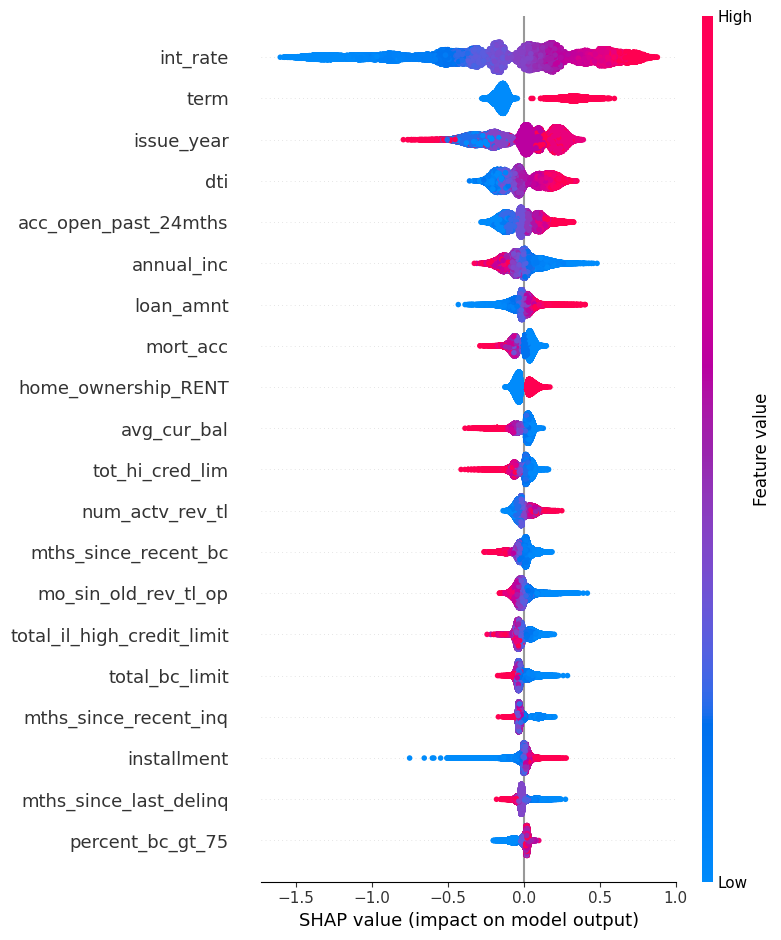

In [2]:
!pip install shap -q

import shap

# TreeExplainer is built for tree models (fast, exact for XGBoost)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — shows top features ranked by impact, colored by feature value
shap.summary_plot(shap_values, X_test, show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

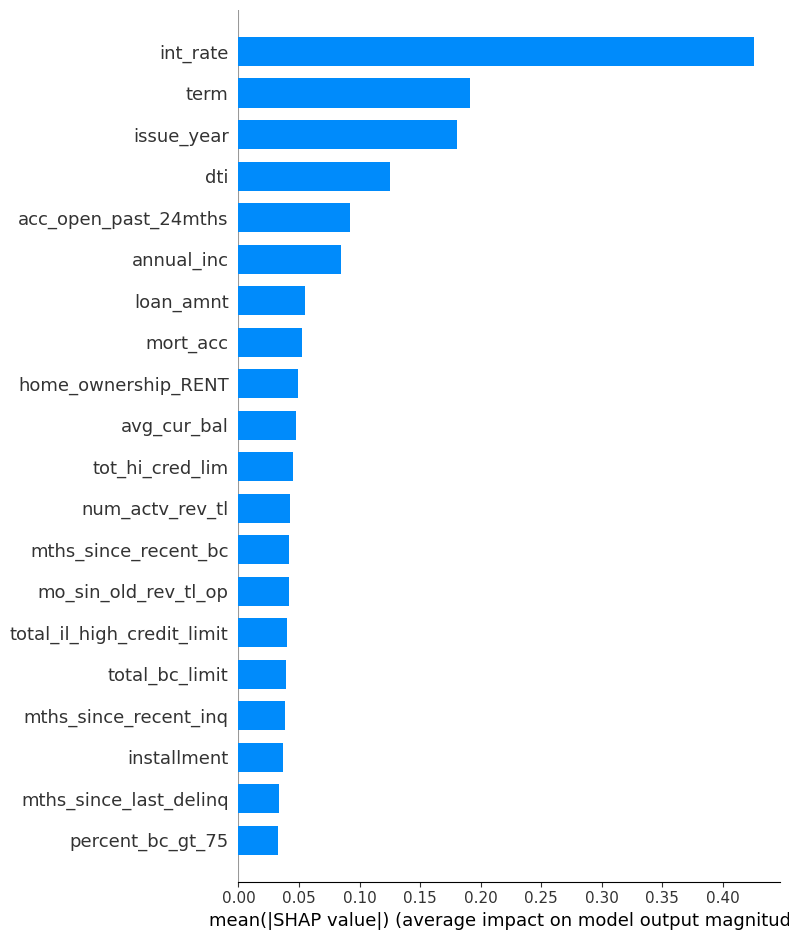

In [3]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Cost-Sensitive Threshold Analysis

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)
results_real = []

for t in thresholds:
    preds = (y_pred_proba_tuned >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    expected_loss = (fn * avg_loan_amount) + (fp * avg_lost_interest_real)
    results_real.append({'threshold': round(t,2), 'FN': fn, 'FP': fp, 'expected_loss': expected_loss})

results_real_df = pd.DataFrame(results_real)
print(results_real_df)

best_real = results_real_df.loc[results_real_df['expected_loss'].idxmin()]
print("\nOptimal threshold (real data):")
print(best_real)

    threshold     FN     FP  expected_loss
0        0.10     40  44905   1.729682e+08
1        0.15    115  42437   1.645517e+08
2        0.20    289  39425   1.554444e+08
3        0.25    565  35961   1.460419e+08
4        0.30    978  31956   1.364967e+08
5        0.35   1509  27776   1.279456e+08
6        0.40   2209  23595   1.217767e+08
7        0.45   3003  19445   1.170541e+08
8        0.50   3961  15529   1.155453e+08
9        0.55   5009  11966   1.166625e+08
10       0.60   6044   8613   1.184024e+08
11       0.65   7233   5867   1.246471e+08
12       0.70   8405   3656   1.327057e+08
13       0.75   9537   1935   1.420809e+08
14       0.80  10565    759   1.520801e+08
15       0.85  11301    165   1.601911e+08

Optimal threshold (real data):
threshold        5.000000e-01
FN               3.961000e+03
FP               1.552900e+04
expected_loss    1.155453e+08
Name: 8, dtype: float64


In [ ]:
import joblib
joblib.dump(best_model, '/content/drive/MyDrive/xgb_tuned_model.pkl')

['/content/drive/MyDrive/xgb_tuned_model.pkl']

In [ ]:
results_real_df.to_csv('/content/drive/MyDrive/threshold_analysis_results.csv', index=False)

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Getting started.pdf', 'Classroom', 'asch.docx', 'Geography (1).docx', 'Geography.docx', 'SANSKRIT.docx', 'SCIENCE (5).docx', 'SCIENCE (4).docx', 'SCIENCE (3).docx', 'SCIENCE (2).docx', 'SCIENCE (1).docx', 'SCIENCE.docx', 'IMG_20200501_223327 (1).JPG', 'IMG_20200501_223327.JPG', 'Edited - Mathematics (Jul 13, 2020 9:35:05 AM) (1).jpeg', 'Edited - Mathematics (Jul 13, 2020 9:35:05 AM).jpeg', 'Edited - Mathematics (Jul 13, 2020 9:35:53 AM).jpeg', 'Resume.gdoc', 'Lh.pdf', 'Arnav Pawar Sanskrit 10-D', 'Arnav Pawar ENGLISH 10-D', 'Arnav Pawar Science 10-D', 'Arnav Pawar Social Science (SST) 10-D', 'Arnav Pawar Mathematics 10-D', 'new doc 2020-09-28 22:44:08 (1).pdf', 'new doc 2020-09-28 22:44:08.pdf', 'new doc 2020-09-28 23:00:40.pdf', 'new doc 2020-09-28 23:05:30.pdf', 'Untitled Jam (1).pdf', 'Untitled Jam.pdf', 'new doc 2020-09-30 12:20:57.pdf', 'new doc 2020-10-09 12:32:24.pdf', 'Edited - Triangles (Post 13) (Aug 6, 2020 10:46:30 PM).jpeg', 'Edited - Triangles (Post 13) (Aug 6, 2020 10:

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=skf, scoring='roc_auc')

print("AUC scores across 5 folds:", cv_scores)
print(f"Mean AUC: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

AUC scores across 5 folds: [0.73357354 0.73223949 0.7317455  0.7282384  0.73154489]
Mean AUC: 0.7315
Std Dev: 0.0018


In [ ]:
import joblib

def predict_risk(applicant_data: dict, threshold=0.50):
    """
    applicant_data: dict with same feature names/order as X_train.columns
    """
    import pandas as pd
    model = joblib.load('/content/drive/MyDrive/xgb_tuned_model.pkl')

    X_new = pd.DataFrame([applicant_data])
    # ensure column order matches training data
    X_new = X_new.reindex(columns=X_train.columns, fill_value=0)

    prob = model.predict_proba(X_new)[:, 1][0]
    decision = "High Risk - Reject" if prob >= threshold else "Low Risk - Approve"

    return {"predicted_default_probability": round(float(prob), 4), "decision": decision}

# test it
sample_applicant = X_test.iloc[0].to_dict()
print(predict_risk(sample_applicant))

{'predicted_default_probability': 0.4441, 'decision': 'Low Risk - Approve'}


In [ ]:
print("Actual outcome:", y_test.iloc[0])  # 0 = Fully Paid, 1 = Charged Off

Actual outcome: 0


In [ ]:
print('addr_state' in df_clean.columns)
print(df_clean['addr_state'].head())
print(df_clean['addr_state'].nunique())

True
2042571    WI
1639689    OK
1682041    FL
982231     TX
1749149    IL
Name: addr_state, dtype: object
51


## 11. Power BI Export

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import joblib

df_clean = pd.read_parquet('/content/drive/MyDrive/lending_club_clean.parquet')
df_model = pd.read_parquet('/content/drive/MyDrive/lending_club_model_ready.parquet')
best_model = joblib.load('/content/drive/MyDrive/xgb_tuned_model.pkl')

X_all = df_model.drop(columns=['target'])
predicted_probs = best_model.predict_proba(X_all)[:, 1]

df_clean['predicted_default_prob'] = predicted_probs
df_clean['risk_segment'] = pd.cut(
    df_clean['predicted_default_prob'],
    bins=[0, 0.25, 0.5, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)
df_clean['predicted_decision'] = df_clean['predicted_default_prob'].apply(
    lambda p: 'Reject' if p >= 0.5 else 'Approve'
)

print(df_clean[['predicted_default_prob', 'risk_segment', 'predicted_decision']].head())
print(df_clean['risk_segment'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
         predicted_default_prob risk_segment predicted_decision
2042571                0.259965  Medium Risk            Approve
1639689                0.574448    High Risk             Reject
1682041                0.170057     Low Risk            Approve
982231                 0.359528  Medium Risk            Approve
1749149                0.284848  Medium Risk            Approve
risk_segment
Medium Risk    119178
High Risk      115975
Low Risk        54847
Name: count, dtype: int64


In [ ]:
df_clean['risk_segment'] = pd.qcut(
    df_clean['predicted_default_prob'],
    q=3,
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print(df_clean['risk_segment'].value_counts())

risk_segment
Low Risk       96667
High Risk      96667
Medium Risk    96666
Name: count, dtype: int64


In [ ]:
df_clean.to_csv('/content/drive/MyDrive/lending_club_for_powerbi.csv', index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df_clean = pd.read_parquet('/content/drive/MyDrive/lending_club_clean.parquet')

print(df_clean.shape)
print(df_clean.columns.tolist())

Mounted at /content/drive
(290000, 70)
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90